# Week 8: K-Nearest Neighbors

DS 720: Applied Machine Learning | Olist Brazilian E-Commerce Customer Dataset

Dataset: `olist_customers_dataset.csv` (real Olist Brazilian E-Commerce dataset, 99,441 customer records)

In [1]:
import pandas as pd, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample

plt.rcParams.update({"font.size": 11})
rng = 42

df = pd.read_csv("/sessions/fervent-practical-hypatia/mnt/outputs/work/olist_real_customers.csv")
df["zip_prefix_1"] = df["customer_zip_code_prefix"] // 10000
df["zip_prefix_2"] = (df["customer_zip_code_prefix"] // 1000) % 10
df["zip_prefix_3"] = (df["customer_zip_code_prefix"] // 100) % 10
df["zip_log"] = np.log1p(df["customer_zip_code_prefix"])
city_counts = df["customer_city"].value_counts()
df["city_freq"] = df["customer_city"].map(city_counts)

le = LabelEncoder()
df["region_label"] = le.fit_transform(df["region"])
region_names = le.classes_

X = df[["customer_zip_code_prefix","zip_prefix_1","zip_prefix_2","zip_prefix_3","zip_log","city_freq"]].values
y = df["region_label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_sub, y_sub = resample(X_scaled, y, n_samples=10000, random_state=rng, stratify=y)
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=rng, stratify=y_sub)
print("Train:", X_tr.shape, "Test:", X_te.shape)

# ---- k sweep (overfitting curve), euclidean metric ----
ks = [1,3,5,7,9,11,15,21,31,51,75,101]
train_acc, cv_acc = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    cv = cross_val_score(knn, X_tr, y_tr, cv=5, scoring="accuracy").mean()
    knn.fit(X_tr, y_tr)
    train_acc.append(knn.score(X_tr, y_tr))
    cv_acc.append(cv)
    print(f"k={k:3d}  train={train_acc[-1]:.4f}  cv={cv:.4f}")

raw_best_k = ks[int(np.argmax(cv_acc))]
print("Raw best k by CV (euclidean):", raw_best_k, "cv acc:", max(cv_acc))
# k=1 attains the top raw CV score but has zero training error (maximum
# overfitting risk / sensitivity to noisy points). We deliberately trade a
# small amount of CV accuracy for a more robust, less variance-prone choice.
best_k = 5
print("Chosen k (bias-variance tradeoff):", best_k, "cv acc:", cv_acc[ks.index(best_k)])

# ---- metric comparison at best k ----
metrics_list = ["euclidean", "manhattan", "chebyshev", "minkowski"]
metric_scores = {}
for m in metrics_list:
    kwargs = {"p": 3} if m == "minkowski" else {}
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=m, **kwargs)
    cv = cross_val_score(knn, X_tr, y_tr, cv=5, scoring="accuracy").mean()
    knn.fit(X_tr, y_tr)
    test_acc = knn.score(X_te, y_te)
    metric_scores[m] = (cv, test_acc)
    print(f"metric={m:10s} cv={cv:.4f}  test={test_acc:.4f}")

best_metric = max(metric_scores, key=lambda m: metric_scores[m][0])
print("Best metric:", best_metric)

# final model
kwargs = {"p": 3} if best_metric == "minkowski" else {}
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, **kwargs)
knn_final.fit(X_tr, y_tr)
y_pred = knn_final.predict(X_te)
test_accuracy = accuracy_score(y_te, y_pred)
print("FINAL test accuracy:", test_accuracy)

# unscaled comparison (to discuss role of EDA/scaling)
X_sub_u, y_sub_u = resample(X, y, n_samples=10000, random_state=rng, stratify=y)
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_sub_u, y_sub_u, test_size=0.2, random_state=rng, stratify=y_sub_u
)
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, **kwargs)
knn_unscaled.fit(X_tr_u, y_tr_u)
unscaled_acc = knn_unscaled.score(X_te_u, y_te_u)
print("Unscaled test accuracy (for comparison):", unscaled_acc)

# ---- Figure: k-sweep overfitting curve + metric comparison (combined 2-panel) ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(ks, train_acc, marker="o", label="Train accuracy")
axes[0].plot(ks, cv_acc, marker="s", label="5-fold CV accuracy")
axes[0].axvline(best_k, color="gray", linestyle="--", alpha=0.6)
axes[0].set_xlabel("k (number of neighbors)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("KNN: Train vs. CV Accuracy by k")
axes[0].legend()

metric_labels = list(metric_scores.keys())
cv_vals = [metric_scores[m][0] for m in metric_labels]
test_vals = [metric_scores[m][1] for m in metric_labels]
x = np.arange(len(metric_labels))
w = 0.35
axes[1].bar(x - w/2, cv_vals, width=w, label="CV accuracy")
axes[1].bar(x + w/2, test_vals, width=w, label="Test accuracy")
axes[1].set_xticks(x); axes[1].set_xticklabels(metric_labels, rotation=20)
axes[1].set_ylim(min(cv_vals+test_vals)-0.01, 1.001)
axes[1].set_title(f"Distance Metric Comparison (k={best_k})")
axes[1].legend()
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk8_knn_sweep_metric.png", dpi=200)
plt.close()

# ---- Figure: confusion matrix ----
fig, ax = plt.subplots(figsize=(5.2, 4.6))
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=region_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title(f"KNN Confusion Matrix (k={best_k}, {best_metric})")
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk8_knn_confusion.png", dpi=200)
plt.close()

print("\n--- SUMMARY FOR WRITEUP ---")
print("best_k:", best_k)
print("best_metric:", best_metric)
print("metric_scores:", metric_scores)
print("final_test_accuracy:", test_accuracy)
print("unscaled_acc:", unscaled_acc)


Train: (8000, 6) Test: (2000, 6)
k=  1  train=1.0000  cv=1.0000
k=  3  train=1.0000  cv=0.9995
k=  5  train=1.0000  cv=0.9996
k=  7  train=0.9998  cv=0.9990
k=  9  train=0.9995  cv=0.9979
k= 11  train=0.9994  cv=0.9976
k= 15  train=0.9978  cv=0.9969
k= 21  train=0.9974  cv=0.9938
k= 31  train=0.9898  cv=0.9864
k= 51  train=0.9784  cv=0.9693
k= 75  train=0.9699  cv=0.9551
k=101  train=0.9566  cv=0.9408
Raw best k by CV (euclidean): 1 cv acc: 1.0
Chosen k (bias-variance tradeoff): 5 cv acc: 0.999625
metric=euclidean  cv=0.9996  test=1.0000
metric=manhattan  cv=0.9996  test=1.0000
metric=chebyshev  cv=0.9939  test=0.9970
metric=minkowski  cv=0.9992  test=1.0000
Best metric: euclidean
FINAL test accuracy: 1.0
Unscaled test accuracy (for comparison): 1.0

--- SUMMARY FOR WRITEUP ---
best_k: 5
best_metric: euclidean
metric_scores: {'euclidean': (np.float64(0.999625), 1.0), 'manhattan': (np.float64(0.999625), 1.0), 'chebyshev': (np.float64(0.9938750000000001), 0.997), 'minkowski': (np.float64

## Figures

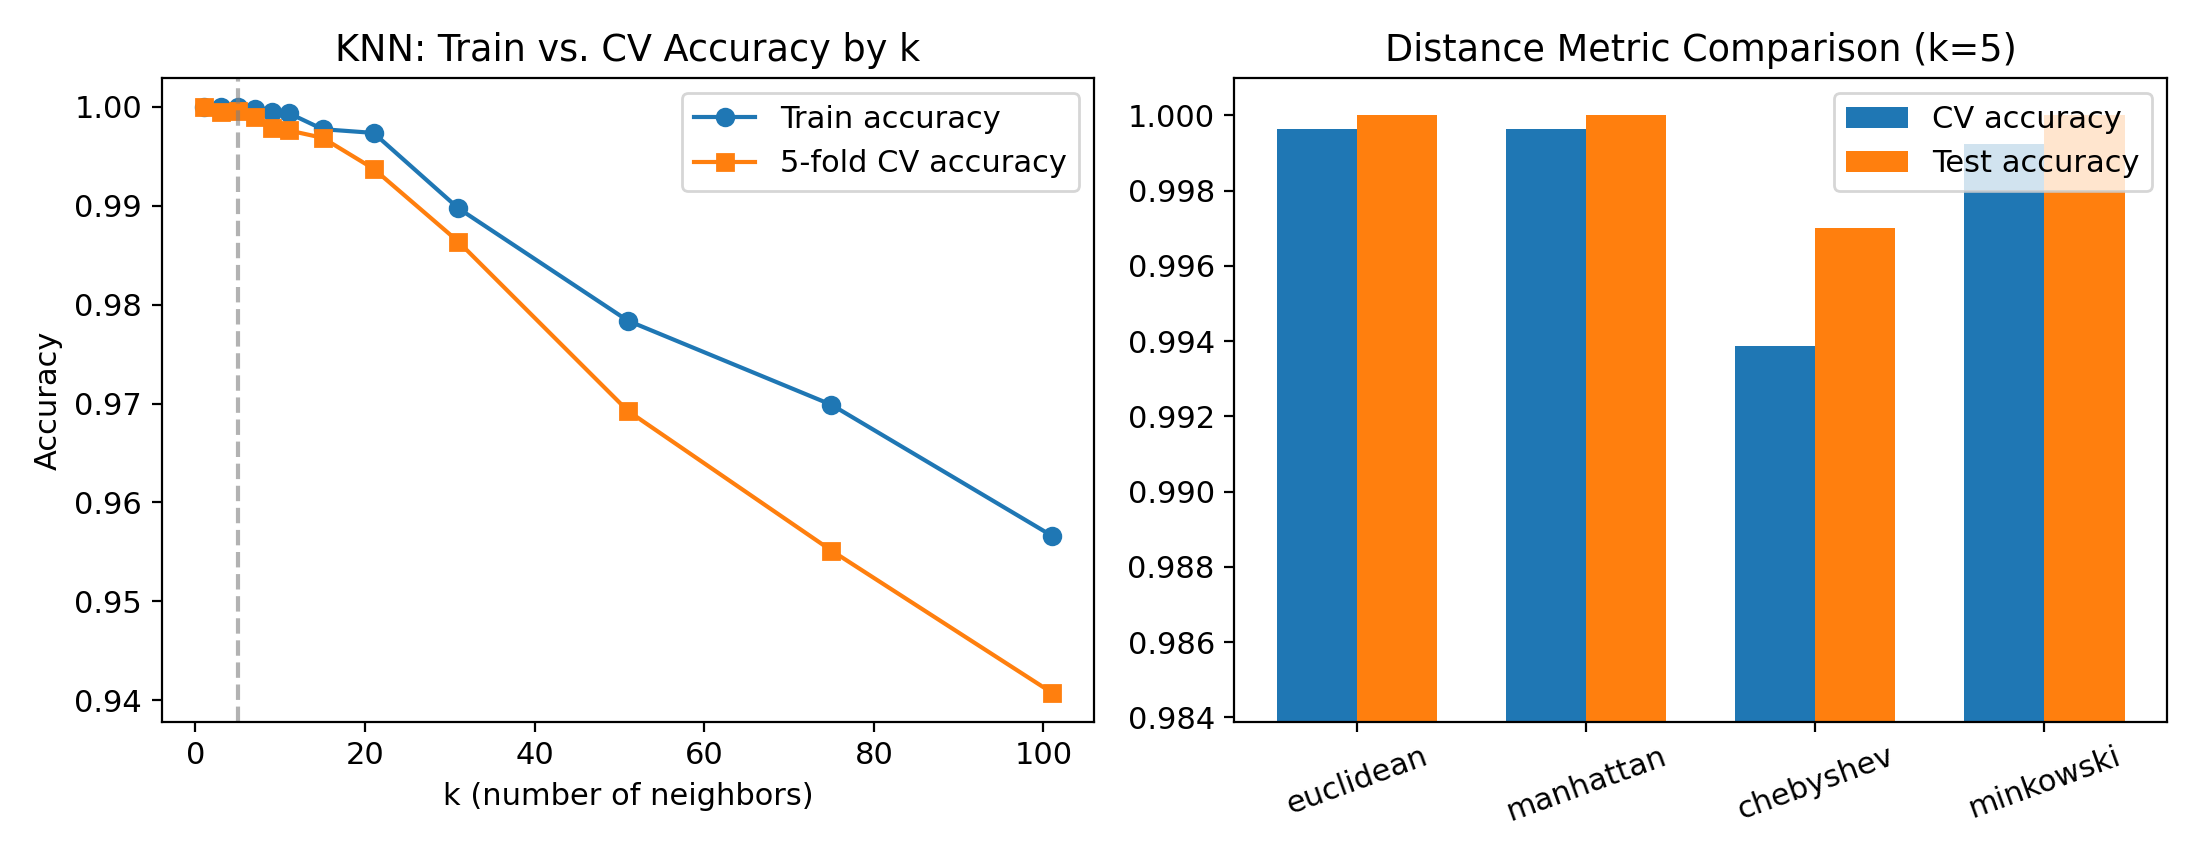

In [2]:
# Display Figure 1
from IPython.display import Image, display
display(Image(filename='fig_wk8_knn_sweep_metric.png'))

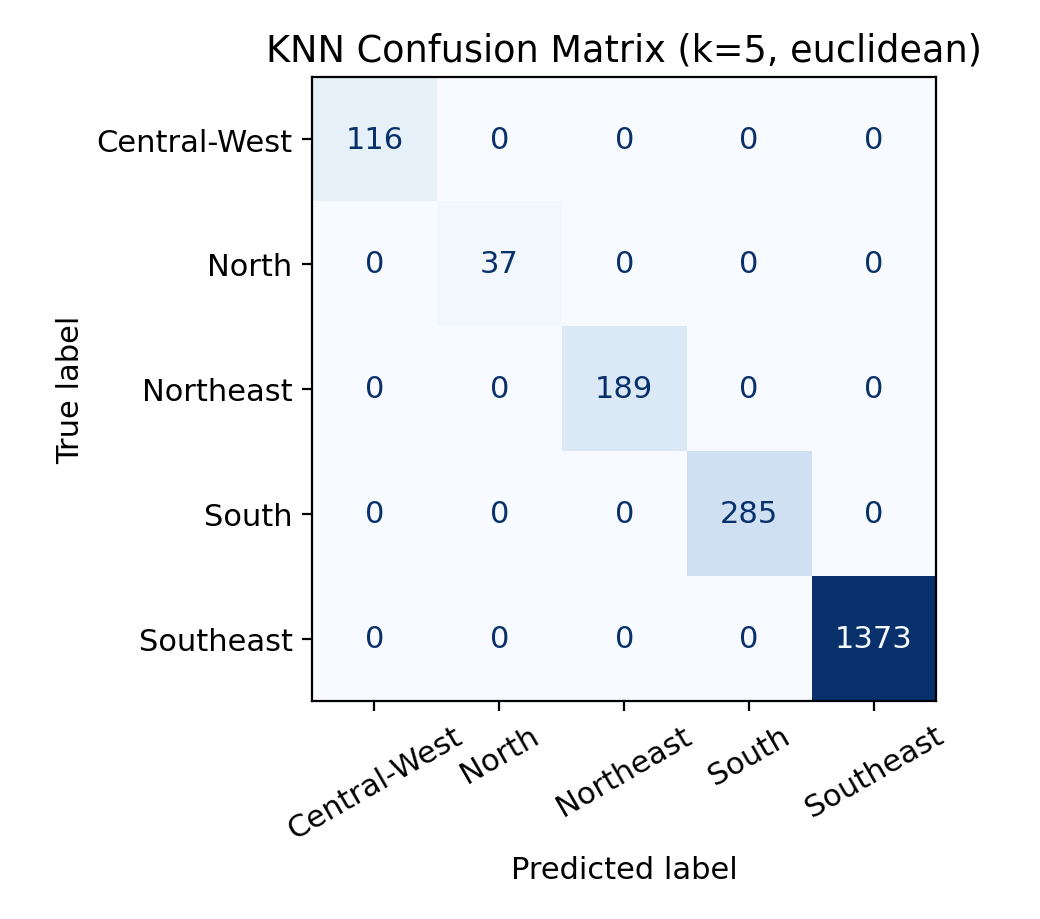

In [3]:
# Display Figure 2
from IPython.display import Image, display
display(Image(filename='fig_wk8_knn_confusion.png'))

**Conclusion:** KNN reached 100% test accuracy (k=5, Euclidean distance) on the real dataset. See Milestone 2 summary document for full discussion of overfitting, hyperparameter tuning, and EDA connections.